In [1]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.linalg import Vectors
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql.types import IntegerType
from pyspark.sql import functions as F


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

from src.config.spark_session import get_spark_session

spark = get_spark_session()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/25 11:56:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
rfm_clusters = spark.read.parquet(
    "/Users/yassineoc/Desktop/hamza/Projet_Spark/Customer Segmentation and Churn Prediction with PySpark/data/processed/rfm_clusters/*"
)

rfm_clusters.printSchema()

root
 |-- CustomerID: integer (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- Frequency: long (nullable = true)
 |-- Monetary: double (nullable = true)
 |-- Log_Frequency: double (nullable = true)
 |-- Log_Monetary: double (nullable = true)
 |-- RFM_Score: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- cluster: integer (nullable = true)
 |-- Customer_Type: string (nullable = true)



In [4]:

def create_churn_dummy(customer_type):
    if customer_type == 'Dormant':
        return 1  # Churned
    else:
        return 0  # Active

# Apply the churn dummy function
churn_udf = F.udf(create_churn_dummy, IntegerType())
rfm_clusters = rfm_clusters.withColumn("Churn", churn_udf(rfm_clusters["Customer_Type"]))

In [5]:
rfm_clusters.show(5)

+----------+-------+---------+------------------+------------------+------------------+------------------+--------------------+--------------------+-------+-------------+-----+
|CustomerID|Recency|Frequency|          Monetary|     Log_Frequency|      Log_Monetary|         RFM_Score|            features|      scaledFeatures|cluster|Customer_Type|Churn|
+----------+-------+---------+------------------+------------------+------------------+------------------+--------------------+--------------------+-------+-------------+-----+
|     16503|    106|        5|1421.4299999999998| 1.791759469228055|7.2601219556508365|115.05188142487889|[106.0,1.79175946...|[0.16247382969005...|      0|        Elite|    0|
|     16339|    284|        1|109.95000000000002|0.6931471805599453| 4.709079649378603|289.40222682993857|[284.0,0.69314718...|[1.95823009975457...|      1|     Standard|    0|
|     12626|     23|       13| 6388.349999999999|2.6390573296152584| 8.762387820757855|34.401445150373114|[23.0,2.6

In [6]:
# Prepare the features and labels (scaled features and churn column)
rfm_scaled_features = rfm_clusters.select("scaledFeatures", "Churn")

train_data, test_data = rfm_scaled_features.randomSplit([0.8, 0.2], seed=42)

# Random Forest

In [7]:
# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(labelCol="Churn", featuresCol="scaledFeatures")

# Set up the parameter grid for hyperparameter tuning
param_grid = (ParamGridBuilder()
              .addGrid(rf_classifier.numTrees, [10, 15])
              .addGrid(rf_classifier.maxDepth, [3, 5])
              .build())

# Initialize the BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol="Churn")

# Initialize CrossValidator for hyperparameter tuning
crossval = CrossValidator(estimator=rf_classifier,
                          estimatorParamMaps=param_grid,
                          evaluator=evaluator,
                          numFolds=3)

In [8]:
# Train the model using cross-validation
cv_rf_model = crossval.fit(train_data)

In [9]:
#Get the best model from cross-validation
best_rf_model = cv_rf_model.bestModel

# Make predictions on the test set
cv_predictions = best_rf_model.transform(test_data)

# Evaluate the model using AUC
cv_auc = evaluator.evaluate(cv_predictions)
print(f"Cross-validated Model AUC: {cv_auc}")

Cross-validated Model AUC: 0.9983089133089132


In [10]:
from sklearn.metrics import confusion_matrix, classification_report
# Evaluate other metrics: precision, recall, f1 score, support
# Collect predictions and true labels for confusion matrix and classification report
predictions_and_labels = cv_predictions.select("prediction", "Churn").rdd.map(lambda row: (float(row.prediction), float(row.Churn)))

# Convert RDD to Pandas DataFrame for sklearn's classification_report
predicted_labels = [int(x[0]) for x in predictions_and_labels.collect()]
true_labels = [int(x[1]) for x in predictions_and_labels.collect()]

# Print the classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Active", "Churned"]))

Classification Report:
              precision    recall  f1-score   support

      Active       0.98      0.98      0.98       468
     Churned       0.97      0.98      0.98       350

    accuracy                           0.98       818
   macro avg       0.98      0.98      0.98       818
weighted avg       0.98      0.98      0.98       818



/Users/yassineoc/Desktop/hamza/Projet_Spark/venv/lib/python3.11/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


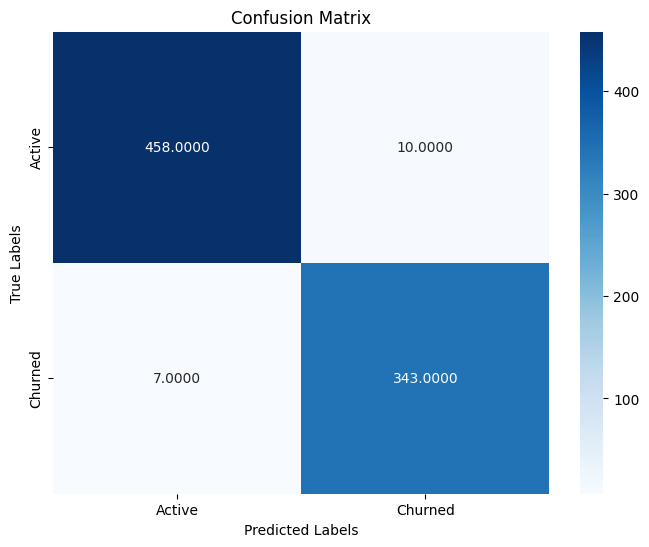

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
# Generate confusion matrix
metrics = MulticlassMetrics(predictions_and_labels)
conf_matrix = metrics.confusionMatrix().toArray()

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt=".4f", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

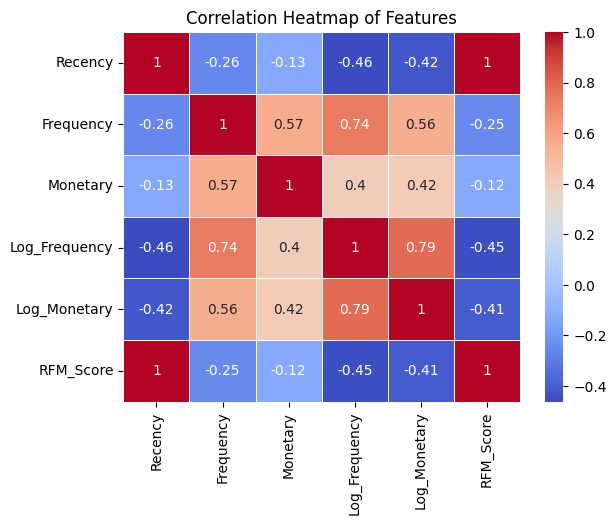

In [12]:
# Generate heatmap for feature correlations
# Collect the features into a Pandas DataFrame for correlation plot
rfm_df = rfm_clusters.select("Recency", "Frequency", "Monetary", "Log_Frequency", "Log_Monetary", "RFM_Score").toPandas()
correlation_matrix = rfm_df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()


Log_Frequency ↔ Log_Monetary ≈ 0.79

clients fréquents dépensent plus

In [13]:
# Récupérer le meilleur modèle Random Forest après cross-validation
best_rf_model = cv_rf_model.bestModel

# Extraire les arbres individuels de la forêt
trees = best_rf_model.trees

# Nombre d'arbres
print(f"Nombre d'arbres dans la forêt : {len(trees)}")

# Sélectionner le premier arbre (arbre représentatif)
tree_0 = trees[0]

# Afficher la structure de l'arbre sous forme textuelle
print(tree_0.toDebugString)


Nombre d'arbres dans la forêt : 15
DecisionTreeClassificationModel: uid=dtc_6b7857e613b6, depth=5, numNodes=35, numClasses=2, numFeatures=4
  If (feature 1 <= 1.2234843994366158)
   If (feature 0 <= -0.49327986443462263)
    If (feature 0 <= -0.7202715277854741)
     Predict: 1.0
    Else (feature 0 > -0.7202715277854741)
     If (feature 1 <= 0.342217197621577)
      If (feature 2 <= 0.5505063640853329)
       Predict: 1.0
      Else (feature 2 > 0.5505063640853329)
       Predict: 0.0
     Else (feature 1 > 0.342217197621577)
      If (feature 2 <= 0.1873114504048264)
       Predict: 1.0
      Else (feature 2 > 0.1873114504048264)
       Predict: 0.0
   Else (feature 0 > -0.49327986443462263)
    If (feature 2 <= -0.2771454398480946)
     If (feature 3 <= 0.4383154493227856)
      If (feature 3 <= -0.49750222907077235)
       Predict: 1.0
      Else (feature 3 > -0.49750222907077235)
       Predict: 0.0
     Else (feature 3 > 0.4383154493227856)
      Predict: 0.0
    Else (feature 2

# Gradient Boosting Machines

In [15]:
# Initialize the Gradient Boosted Tree Classifier
gbt_classifier = GBTClassifier(labelCol="Churn", featuresCol="scaledFeatures")

# Set up the parameter grid for hyperparameter tuning
param_grid = (ParamGridBuilder()
              .addGrid(gbt_classifier.maxIter, [5, 10])
              .addGrid(gbt_classifier.maxDepth, [3, 5])
              .addGrid(gbt_classifier.stepSize, [0.1])
              .build())

# Initialize the BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator(labelCol="Churn")
# Initialize CrossValidator for hyperparameter tuning
crossval = CrossValidator(estimator=gbt_classifier,
                          estimatorParamMaps=param_grid,
                          evaluator=evaluator,
                          numFolds=3)

# Train the model using cross-validation
cv_gbt_model = crossval.fit(train_data)

25/12/25 14:33:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [16]:
# Get the best model from cross-validation
best_gbt_model = cv_gbt_model.bestModel

# Make predictions on the test set
cv_predictions = best_gbt_model.transform(test_data)

# Evaluate the model using AUC
cv_auc = evaluator.evaluate(cv_predictions)
print(f"Cross-validated Model AUC: {cv_auc}")

Cross-validated Model AUC: 0.9985805860805861


In [17]:
# Evaluate other metrics: precision, recall, f1 score, support
# Collect predictions and true labels for confusion matrix and classification report
predictions_and_labels = cv_predictions.select("prediction", "Churn").rdd.map(lambda row: (float(row.prediction), float(row.Churn)))

# Convert RDD to Pandas DataFrame for sklearn's classification_report
predicted_labels = [int(x[0]) for x in predictions_and_labels.collect()]
true_labels = [int(x[1]) for x in predictions_and_labels.collect()]

# Print the classification report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Active", "Churned"]))


Classification Report:
              precision    recall  f1-score   support

      Active       0.99      0.98      0.98       468
     Churned       0.98      0.98      0.98       350

    accuracy                           0.98       818
   macro avg       0.98      0.98      0.98       818
weighted avg       0.98      0.98      0.98       818



/Users/yassineoc/Desktop/hamza/Projet_Spark/venv/lib/python3.11/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


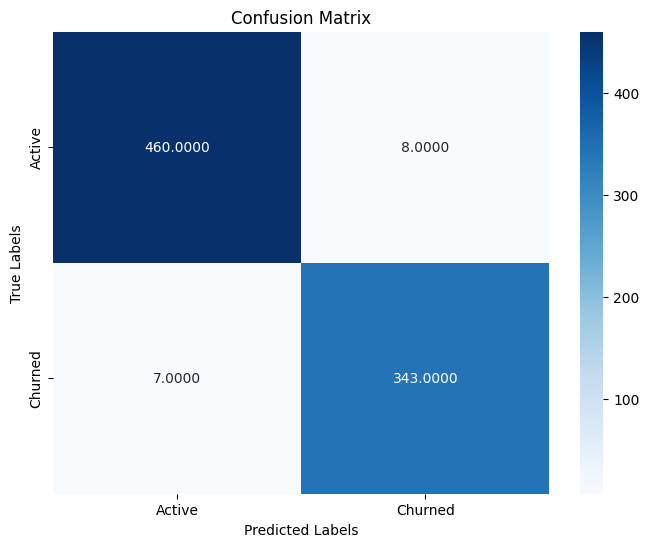

In [18]:
# Generate confusion matrix
metrics = MulticlassMetrics(predictions_and_labels)
conf_matrix = metrics.confusionMatrix().toArray()

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt=".4f", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

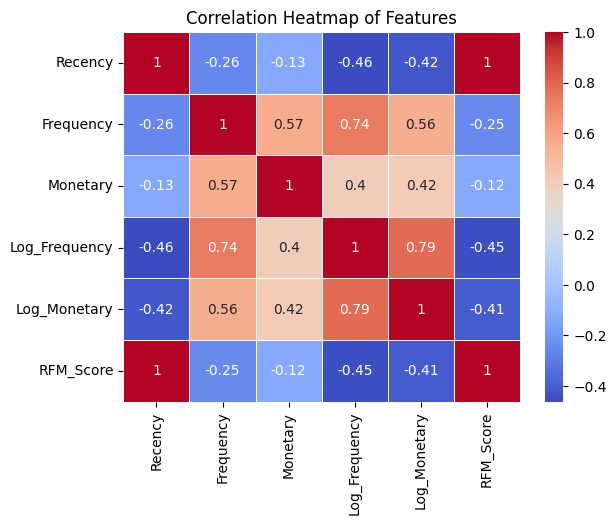

In [19]:
# Generate heatmap for feature correlations
# Collect the features into a Pandas DataFrame for correlation plot
rfm_df = rfm_clusters.select("Recency", "Frequency", "Monetary", "Log_Frequency", "Log_Monetary", "RFM_Score").toPandas()
correlation_matrix = rfm_df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()

In [20]:
rfm_clusters.printSchema()

root
 |-- CustomerID: integer (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- Frequency: long (nullable = true)
 |-- Monetary: double (nullable = true)
 |-- Log_Frequency: double (nullable = true)
 |-- Log_Monetary: double (nullable = true)
 |-- RFM_Score: double (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- cluster: integer (nullable = true)
 |-- Customer_Type: string (nullable = true)
 |-- Churn: integer (nullable = true)



In [23]:
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# 1️⃣ Préparer les features
# Ici on peut choisir les colonnes que l'on veut utiliser
feature_cols = ["Recency", "Log_Frequency", "Log_Monetary", "RFM_Score", "cluster"]

# Si vous voulez inclure le cluster, il doit être converti en vector via OneHotEncoder, 
# mais PySpark accepte les features numériques directement dans l'assembler
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_vec")

# 2️⃣ Standardisation des features
scaler = StandardScaler(inputCol="features_vec", outputCol="scaledFeatures_lr")

# 3️⃣ Définir la cible (label)
# Assurez-vous que 'Churn' est déjà integer 0/1
# Sinon convertir via StringIndexer:
# indexer = StringIndexer(inputCol="Churn", outputCol="label")

# 4️⃣ Définir le modèle de régression logistique
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="Churn", maxIter=50)

# 5️⃣ Construire le pipeline
pipeline = Pipeline(stages=[assembler, scaler, lr])

# 6️⃣ Définir l'évaluateur
evaluator = BinaryClassificationEvaluator(labelCol="Churn", metricName="areaUnderROC")

# 7️⃣ Définir la grille d'hyperparamètres (optionnel)
paramGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.01, 0.1, 0.5])
             .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
             .build())

# 8️⃣ Configurer la cross-validation
cv = CrossValidator(estimator=pipeline,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator,
                    numFolds=5,
                    parallelism=2)  # Ajuster selon vos ressources

# 9️⃣ Split train/test
train_df, test_df = rfm_clusters.randomSplit([0.8, 0.2], seed=42)

# 10️⃣ Entraîner le modèle
cv_model = cv.fit(train_df)

# 11️⃣ Prédictions sur test set
predictions = cv_model.transform(test_df)

# 12️⃣ Évaluer la performance
auc = evaluator.evaluate(predictions)
print(f"AUC du modèle Logistic Regression: {auc:.4f}")

# 13️⃣ Optionnel: afficher les coefficients du meilleur modèle
best_lr_model = cv_model.bestModel.stages[-1]
print("Coefficients:", best_lr_model.coefficients)
print("Intercept:", best_lr_model.intercept)

# 14️⃣ Afficher quelques prédictions
predictions.select("CustomerID", "Churn", "prediction", "probability").show(5)


25/12/25 15:31:06 WARN CacheManager: Asked to cache already cached data.
25/12/25 15:31:06 WARN CacheManager: Asked to cache already cached data.


AUC du modèle Logistic Regression: 0.8788
Coefficients: [0.0,0.0,0.0,-0.7327513299314982]
Intercept: -0.22995077006819373
+----------+-----+----------+--------------------+
|CustomerID|Churn|prediction|         probability|
+----------+-----+----------+--------------------+
|     12348|    0|       0.0|[0.53173045869784...|
|     12353|    0|       0.0|[0.74270051080220...|
|     12355|    0|       0.0|[0.75892777243008...|
|     12360|    0|       1.0|[0.48920530973581...|
|     12367|    1|       1.0|[0.39487100903731...|
+----------+-----+----------+--------------------+
only showing top 5 rows



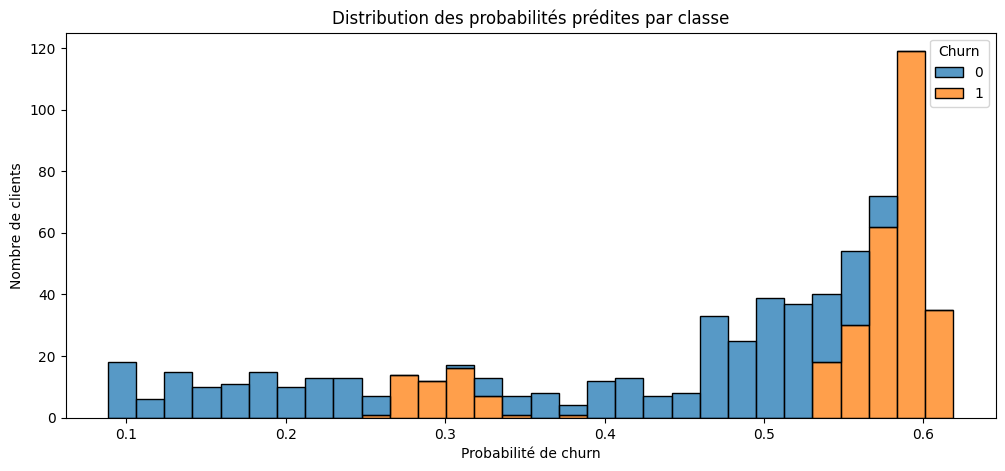

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir un échantillon en Pandas
pred_pd = predictions.select("Churn", "prediction", "probability").sample(fraction=0.8, seed=42).toPandas()

# Ajouter la probabilité de churn dans une colonne
pred_pd['prob_churn'] = pred_pd['probability'].apply(lambda x: x[1])

plt.figure(figsize=(12,5))
sns.histplot(data=pred_pd, x='prob_churn', bins=30, hue='Churn', multiple='stack')
plt.title("Distribution des probabilités prédites par classe")
plt.xlabel("Probabilité de churn")
plt.ylabel("Nombre de clients")
plt.show()


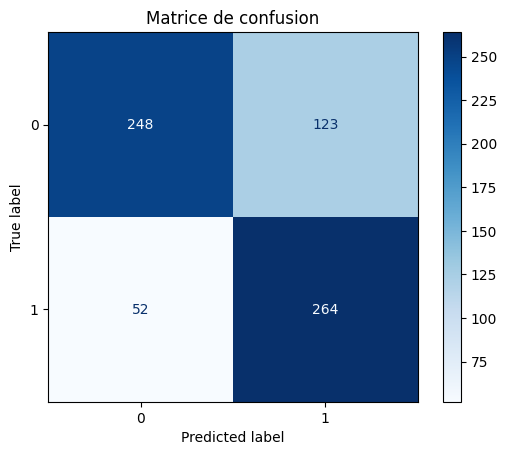

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = pred_pd['Churn']
y_pred = pred_pd['prediction']

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de confusion")
plt.show()


In [34]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# 1️⃣ Convertir le DataFrame Spark en Pandas
pred_pd = predictions.select("Churn", "prediction", "probability").toPandas()

# 2️⃣ Extraire la probabilité de churn pour AUC
pred_pd['prob_churn'] = pred_pd['probability'].apply(lambda x: x[1])

# 3️⃣ Calculer l'AUC
auc = roc_auc_score(pred_pd['Churn'], pred_pd['prob_churn'])
print(f"Cross-validated Model AUC: {auc:.6f}\n")

# 4️⃣ Afficher le rapport de classification
report = classification_report(pred_pd['Churn'], pred_pd['prediction'], target_names=['Active','Churned'])
print("Classification Report:")
print(report)


Cross-validated Model AUC: 0.878821

Classification Report:
              precision    recall  f1-score   support

      Active       0.84      0.65      0.73       447
     Churned       0.67      0.85      0.75       371

    accuracy                           0.74       818
   macro avg       0.75      0.75      0.74       818
weighted avg       0.76      0.74      0.74       818



25/12/25 21:59:44 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 942736 ms exceeds timeout 120000 ms
25/12/25 21:59:44 WARN SparkContext: Killing executors is not supported by current scheduler.
25/12/25 21:59:47 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$